# 실습문제 7 프로젝트 과제 ----------------------------------------------------------------
현재 Grocery 데이터 대신 다른 데이터를 사용하여 연관분석을 수행하시오.

### 후보 데이터 --- 아래 4 개 중 하나 받아와서 씀
* Online Retail Dataset (UCI)
* Instacart Market Basket Dataset
* Kaggle Grocery Dataset
* E-Commerce Transaction Dataset

## 수행 내용
1. 데이터 수집
2. 거래 데이터 전처리
3. One-Hot Encoding
4. Support 계산
5. Confidence 계산
6. Lift 계산
7. 규칙 생성
8. 추천 상품 도출
9. 시각화
10. 결과 보고서 작성

## 최종 프로젝트 보고서 문항
1. 사용한 데이터셋 설명
2. 전체 거래 수
3. 전체 상품 수
4. 가장 많이 판매된 상품
5. 생성된 규칙 수
6. 최고 Support 규칙
7. 최고 Confidence 규칙
8. 최고 Lift 규칙
9. 추천 시스템 결과
10. 비즈니스 활용 방안


## 1. 데이터 수집


### 임포트 & 시드 & 연산장치 설정

In [1]:
# pip install
!pip install python-calamine
!pip install mlxtend

# import
import os, urllib.request, pandas as pd
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# from google.colab import files

# seed
SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 장치:', device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.1/935.1 kB 17.4 MB/s eta 0:00:00
사용 장치: cuda


### 한글 폰트 설치

In [2]:
os.system("apt-get -qq -y install fonts-nanum")

import matplotlib.font_manager as fm

# 설치된 나눔바른고딕 경로를 찾아서 직접 매트플롯립에 등록합니다.
font_path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

# 전역 폰트 적용 및 마이너스 기호 깨짐 방지
plt.rc("font", family=font_name)
plt.rcParams["axes.unicode_minus"] = False

### 데이터 설치 - E-Commerce Transaction Dataset

In [3]:
import os, urllib.request, zipfile, pandas as pd

URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
ZIP_PATH = "data/online_retail.zip"

os.makedirs("data", exist_ok=True)
if not os.path.exists(ZIP_PATH):
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print("다운로드 완료:", ZIP_PATH)

# with zipfile.ZipFile(ZIP_PATH) as z:
#     print("zip 내부 파일:", z.namelist())
#     xlsx_name = [n for n in z.namelist() if n.lower().endswith(".xlsx")][0]
#     with z.open(xlsx_name) as f:
#         df = pd.read_excel(f, engine="openpyxl")


다운로드 완료: data/online_retail.zip


## 2. 거래 데이터 전처리

### 코드 1 - openpyxl 사용

- 로드속도 1분

- 데이터를 단순 for 문으로 작업해서 느림. 메모리 많이 먹음

- df.groupby().apply(...) 이 많이 느림


In [4]:
# import os, zipfile, pandas as pd

# ZIP_PATH = "data/online_retail.zip"

# # 1) zip 안의 xlsx 를 다시 읽어 df 를 깨끗한 DataFrame 으로 복구합니다.
# with zipfile.ZipFile(ZIP_PATH) as z:
#     xlsx_name = [n for n in z.namelist() if n.lower().endswith(".xlsx")][0]
#     with z.open(xlsx_name) as f:
#         df = pd.read_excel(f, engine="openpyxl")

# print(df.shape)
# df.head()

# # 결측치 확인
# print(df.isnull().sum())
# missing_ratio = (df.isnull().sum() / len(df)) * 100
# print(missing_ratio.sort_values(ascending=False))

# df.info()
# print("-----------------------------------------")

# # 2) DataFrame 인지, 컬럼이 뭔지 확인합니다.
# print("타입:", type(df).__name__)
# print("컬럼:", list(df.columns))
# print("-----------------------------------------")

# # 3) 버전별 컬럼 이름 표준화
# df = df.rename(columns={"Invoice": "InvoiceNo", "Customer ID": "CustomerID"})
# print("-----------------------------------------")

# # 4) 결측/취소/음수수량 정리
# df = df.dropna(subset=["Description", "CustomerID"]).copy()
# df["Description"] = df["Description"].astype(str).str.strip()
# df = df[df["Quantity"] > 0]
# df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
# print("-----------------------------------------")

# # 5) 거래(InvoiceNo)별 상품 리스트로 변환
# transactions = df.groupby("InvoiceNo")["Description"].apply(lambda s: list(set(s))).tolist()

# num_transactions = len(transactions)
# all_items = sorted(set(item for t in transactions for item in t))
# num_items = len(all_items)

# print("-----------------------------------------")
# print("전체 거래 수:", num_transactions)
# print("전체 고유 아이템 수:", num_items)
# print("처음 5개 거래:")
# for i, t in enumerate(transactions[:5], start=1):
#     print(f"거래 {i}:", t)
# print("-----------------------------------------")


### 코드 2 - 판다스 백터 & calamine 사용

- 로드 속도 15~22 sec

In [5]:
import os, zipfile, pandas as pd

ZIP_PATH = "data/online_retail.zip"

# 1. calamine 엔진으로 초고속 로드
with zipfile.ZipFile(ZIP_PATH) as z:
    xlsx_name = [n for n in z.namelist() if n.lower().endswith(".xlsx")][0]
    with z.open(xlsx_name) as f:
        df = pd.read_excel(f, engine="calamine")

print("1단계 완료: 깨끗한 원본 데이터 초고속 로드 성공 (행/열):", df.shape)

# 2. 기초 전처리
df = df.rename(columns={"Invoice": "InvoiceNo", "Customer ID": "CustomerID"})
df = df.dropna(subset=["Description", "CustomerID"]).copy()
df["Description"] = df["Description"].astype(str).str.strip()

# *** [교정 완료] 맨 끝 괄호 구문을 ).astype(str).str.startswith("C"))] 로 올바르게 닫았습니다.
df = df[(df["Quantity"] > 0) & (~df["InvoiceNo"].astype(str).str.startswith("C"))]

# 3. 고속 알고리즘 적용하여 리스트 변환
df_unique = df[["InvoiceNo", "Description"]].drop_duplicates()
transactions = df_unique.groupby("InvoiceNo")["Description"].agg(list).tolist()

# 4. 최종 결과 출력
num_transactions = len(transactions)
all_items = sorted(set(item for t in transactions for item in t))
num_items = len(all_items)

print("-----------------------------------------")
print("전체 거래 수:", num_transactions)
print("전체 고유 아이템 수:", num_items)
print("처음 5개 거래:")
for i, t in enumerate(transactions[:5], start=1):
    print(f"거래 {i}:", t)
print("-----------------------------------------")

1단계 완료: 깨끗한 원본 데이터 초고속 로드 성공 (행/열): (541909, 8)
-----------------------------------------
전체 거래 수: 18536
전체 고유 아이템 수: 3866
처음 5개 거래:
거래 1: ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'GLASS STAR FROSTED T-LIGHT HOLDER']
거래 2: ['HAND WARMER UNION JACK', 'HAND WARMER RED POLKA DOT']
거래 3: ['ASSORTED COLOUR BIRD ORNAMENT', "POPPY'S PLAYHOUSE BEDROOM", "POPPY'S PLAYHOUSE KITCHEN", 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'IVORY KNITTED MUG COSY', 'BOX OF 6 ASSORTED COLOUR TEASPOONS', 'BOX OF VINTAGE JIGSAW BLOCKS', 'BOX OF VINTAGE ALPHABET BLOCKS', 'HOME BUILDING BLOCK WORD', 'LOVE BUILDING BLOCK WORD', 'RECIPE BOX WITH METAL HEART', 'DOORMAT NEW ENGLAND']
거래 4: ['JAM MAKING SET WITH JARS', 'RED COAT RACK PARIS FASHION', 'YELLOW COAT RACK PARIS FASHION', 'BLUE COAT RACK PARIS FASHION']
거래 5: ['BATH BUILDING BLOCK WORD']
-------------------

## 3. One-Hot Encoding


### 코드 1 - 직접 구현

 - 러닝타임 2 sec

In [20]:
item_to_idx = {item: idx for idx, item in enumerate(all_items)}

idx_to_item = {idx: item for item, idx in item_to_idx.items()}

X = torch.zeros((num_transactions, num_items), dtype=torch.float32)

for row_idx, transaction in enumerate(transactions):
    for item in transaction:
        col_idx = item_to_idx[item]

        X[row_idx, col_idx] = 1.0

print("one-hot 행렬 크기:", X.shape)

print("처음 5개 거래 x 처음 10개 아이템 행렬:")
print(X[:5, :10])

print("처음 10개 아이템 이름:")
print(all_items[:10])


one-hot 행렬 크기: torch.Size([18536, 3866])
처음 5개 거래 x 처음 10개 아이템 행렬:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
처음 10개 아이템 이름:
['10 COLOUR SPACEBOY PEN', '12 COLOURED PARTY BALLOONS', '12 DAISY PEGS IN WOOD BOX', '12 EGG HOUSE PAINTED WOOD', '12 HANGING EGGS HAND PAINTED', '12 IVORY ROSE PEG PLACE SETTINGS', '12 MESSAGE CARDS WITH ENVELOPES', '12 PENCIL SMALL TUBE WOODLAND', '12 PENCILS SMALL TUBE RED RETROSPOT', '12 PENCILS SMALL TUBE SKULL']


### 코드 2 - mlxtend 사용

 - 0 sec

In [21]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# 1. mlxtend의 전용 인코더 가져오기
te = TransactionEncoder()

# 2. [핵심] 자동으로 아이템을 파악하고 원핫 인코딩된 불린(Boolean) 행렬 생성
# float32 대신 True/False(1비트)를 사용하므로 메모리 사용량이 1/32로 줄어듭니다.
te_ary = te.fit(transactions).transform(transactions)

# 3. 판다스 데이터프레임으로 압축 변환
X_df = pd.DataFrame(te_ary, columns=te.columns_)

print("원핫 행렬 크기:", X_df.shape)
# 앞쪽 5개 행과 10개 열 확인
print(X_df.iloc[:5, :10])

원핫 행렬 크기: (18536, 3866)
   10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
0                   False                       False   
1                   False                       False   
2                   False                       False   
3                   False                       False   
4                   False                       False   

   12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
0                      False                      False   
1                      False                      False   
2                      False                      False   
3                      False                      False   
4                      False                      False   

   12 HANGING EGGS HAND PAINTED  12 IVORY ROSE PEG PLACE SETTINGS  \
0                         False                             False   
1                         False                             False   
2                         False                             False   
3 

## 4. Support 계산

In [8]:
# 1. 전체 거래 수(영수증 수) 파악
num_transactions = len(X_df)

# 2. 각 상품별 지지도(Support) 계산 (열 방향 평균)
item_support = X_df.mean(axis=0)

# 3. 각 상품별 실제 판매 횟수(Count) 계산 (열 방향 합계)
item_count = X_df.sum(axis=0).astype(int)

item_freq_df = pd.DataFrame({
    "item": item_support.index,              # 전체 상품명 (기존 all_items 대체)
    "support": item_support.values,          # 계산된 지지도 비율
    "count": item_count.values               # 계산된 실제 거래 횟수 정수형
})

# 정렬 옵션 (선택 사항: 가장 많이 팔린 상품이 맨 위로 오도록 정렬)
item_freq_df = item_freq_df.sort_values(by="count", ascending=False).reset_index(drop=True)

# 상위 10개 아이템을 출력합니다.
item_freq_df.head(20)


,item,support,count
0,WHITE HANGING HEART T-LIGHT HOLDER,0.106334,1971
1,REGENCY CAKESTAND 3 TIER,0.091929,1704
2,JUMBO BAG RED RETROSPOT,0.086319,1600
3,PARTY BUNTING,0.074450,1380
4,ASSORTED COLOUR BIRD ORNAMENT,0.074180,1375
5,LUNCH BAG RED RETROSPOT,0.069486,1288
6,SET OF 3 CAKE TINS PANTRY DESIGN,0.061826,1146
7,POSTAGE,0.059290,1099
8,LUNCH BAG BLACK SKULL.,0.056754,1052
9,PACK OF 72 RETROSPOT CAKE CASES,0.055514,1029


In [9]:

# 지지도 기준으로 내림차순 정렬합니다.
item_freq_df = item_freq_df.sort_values("support", ascending=False).reset_index(drop=True)

# 상위 10개 아이템을 출력합니다.
item_freq_df.head(20)


,item,support,count
0,WHITE HANGING HEART T-LIGHT HOLDER,0.106334,1971
1,REGENCY CAKESTAND 3 TIER,0.091929,1704
2,JUMBO BAG RED RETROSPOT,0.086319,1600
3,PARTY BUNTING,0.074450,1380
4,ASSORTED COLOUR BIRD ORNAMENT,0.074180,1375
5,LUNCH BAG RED RETROSPOT,0.069486,1288
6,SET OF 3 CAKE TINS PANTRY DESIGN,0.061826,1146
7,POSTAGE,0.059290,1099
8,LUNCH BAG BLACK SKULL.,0.056754,1052
9,PACK OF 72 RETROSPOT CAKE CASES,0.055514,1029


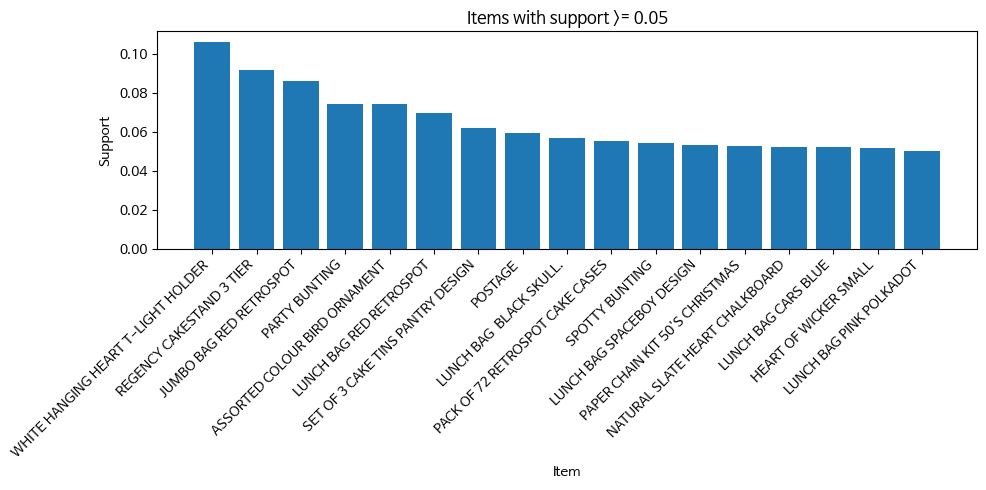

In [10]:
# 지지도 0.05 이상 아이템 시각화
# sup_cut_line = 0.1 # 0.1 에 해당하는 기준 너무 적음
sup_cut_line = 0.05

support_01_df = item_freq_df[item_freq_df["support"] >= sup_cut_line]

plt.figure(figsize=(10, 5))
plt.bar(support_01_df["item"], support_01_df["support"])
plt.xticks(rotation=45, ha="right")

plt.title(f"Items with support >= {sup_cut_line}")
plt.xlabel("Item")
plt.ylabel("Support")

plt.tight_layout()

plt.show()


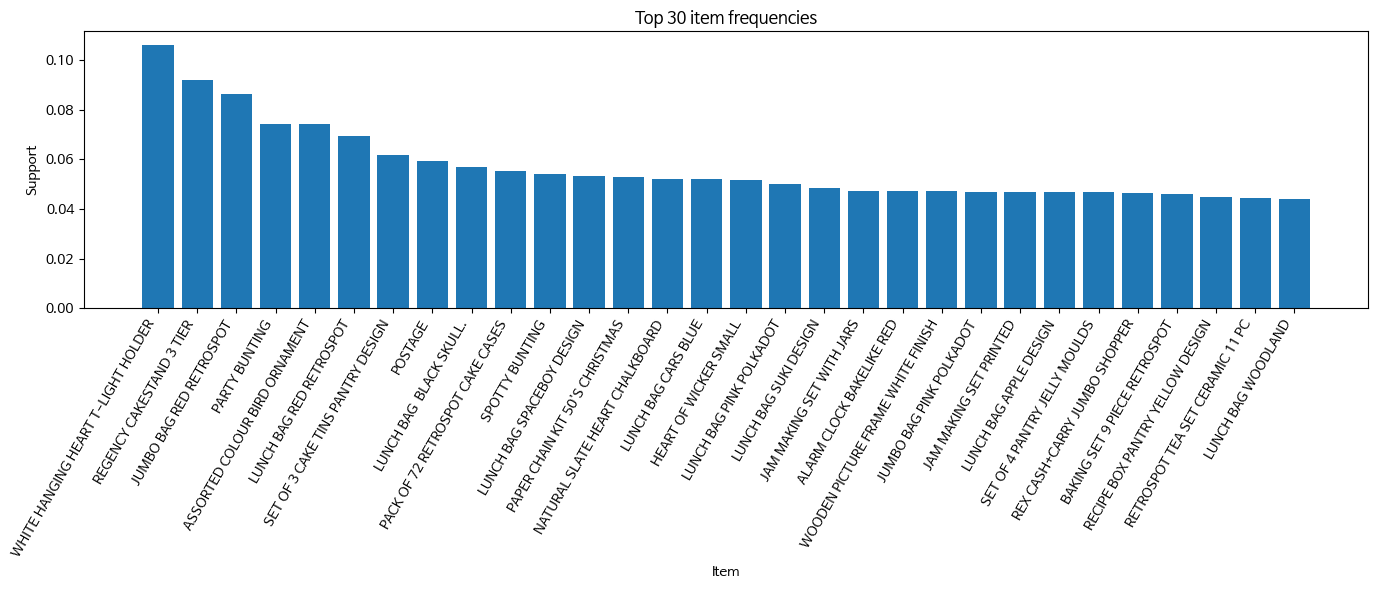

In [11]:
# 지지도 상위 30개 아이템만 선택합니다.
top30_df = item_freq_df.head(30)

plt.figure(figsize=(14, 6))
plt.bar(top30_df["item"], top30_df["support"])
plt.xticks(rotation=60, ha="right")

plt.title("Top 30 item frequencies")
plt.xlabel("Item")
plt.ylabel("Support")
plt.tight_layout()

plt.show()


In [12]:
# itemset 지지도 계산 함수 정의

def calculate_itemset_support(X_dataframe, item_names):
    # item_indices = list(item_indices)
    # selected = X_df[:, item_indices]
    # both_purchased = selected.prod(dim=1)
    # support = both_purchased.mean().item()
    support = X_dataframe[list(item_names)].all(axis=1).mean()
    return float(support)

test_items = item_freq_df.head(2)["item"].tolist()
# test_indices = [item_to_idx[item] for item in test_items]
# test_support = calculate_itemset_support(X_df, test_indices)
test_support = calculate_itemset_support(X_df, test_items)

print("테스트 아이템:", test_items)
print(f"동시 등장 지지도: {test_support:.4f} (전체 거래 중 {test_support*100:.2f}%)")


테스트 아이템: ['WHITE HANGING HEART T-LIGHT HOLDER', 'REGENCY CAKESTAND 3 TIER']
동시 등장 지지도: 0.0127 (전체 거래 중 1.27%)


## 5. Confidence 계산


### 코드 :

In [13]:
confidence_values = [0.1, 0.2, 0.3, 0.4, 0.5]

# frequent_itemsets = {}


### 기존의 apriori 의 연산 속도가 너무 느려서 메모리가 터지는 문제 발생.
=> fpgrowth 로 변경해 문제 해결

### 작업현황 체크 함수

    # fpgrowth 의 처리 속도가 느림 => 동작 하고 있는지 모르겠음
    # => verbose=1 옵션으로 진행상황 print 함 => 이때 출력되는 라인이 너무 많음
    # => 그걸 LogCounter 에서 받아서 진행상황을 뜨고있는 로그의 count 로만 출력

In [14]:
import io
import sys
from IPython.display import clear_output, display

class LogCounter:

    def __init__(self, original_stderr):
        self.original_stderr = original_stderr
        self.log_count = 0

    def write(self, s):
        if s.strip():
            self.log_count += 1
            # 🚨 무한 루프 방지: print() 대신 백업해둔 원래 stderr 스트림을 직접 쥐어짜 출력합니다.
            clear_output(wait=True)
            self.original_stream_print(
                f"🚀 [1단계 진행 중] FP-Growth 알고리즘 가동 (실시간 스캔 추적)\n"
                f"⏳ FP-Tree 조건부 탐색 스캔 횟수: {self.log_count}회 세는 중..."
            )

    def original_stream_print(self, text):
        # original_stderr에 직접 write하면 재귀 루프가 발생하지 않습니다.
        self.original_stderr.write(text)
        self.original_stderr.flush()

    def flush(self):
        self.original_stderr.flush()

### fp-growth 코드

In [15]:
import warnings
import pandas as pd
# [핵심 교체] apriori 대신 fpgrowth
from mlxtend.frequent_patterns import fpgrowth, association_rules
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore', category=DeprecationWarning)

# 실시간 모니터링 로그 가로채기 함수 활성
jupyter_stdout = sys.stderr
logger_intercept = LogCounter(jupyter_stdout)
sys.stdout = logger_intercept

# ============================================================
# 1. [메모리 방어] FP-Growth 기반으로 빈발 아이템셋 초고속 추출
# ============================================================
try :
    # apriori와 입력/출력 형식이 같음
    # verbose=1 옵션으로 진행상황 print 함 => 이때 출력되는 라인이 너무 많음
    # => 그걸 LogCounter 에서 받아서 진행상황을 뜨고있는 로그의 count 로만 출력
    frequent_itemsets_df = fpgrowth(X_df, min_support=0.007, use_colnames=True, verbose=1)
finally :
    # 연산 종료
    sys.stdout = jupyter_stdout

# 길이(개수) 컬럼 추가 및 1~4 필터링
frequent_itemsets_df['length'] = frequent_itemsets_df['itemsets'].apply(len)
frequent_itemsets_df = frequent_itemsets_df[frequent_itemsets_df['length'] <= 4]

print(f" 빈발 아이템셋 추출 완료! (총 {len(frequent_itemsets_df)}개 발견)")


# ============================================================
# 2. 각 Confidence 값별로 규칙 개수 집계
# ============================================================
summary_results = []

for value in tqdm(confidence_values, desc="📊 신뢰도 구간 연산률"):

    try:
        rules_df = association_rules(frequent_itemsets_df, metric="confidence", min_threshold=value)
    except TypeError:
        rules_df = association_rules(frequent_itemsets_df, num_itemsets=len(frequent_itemsets_df), metric="confidence", min_threshold=value)

    num_single = len(frequent_itemsets_df[frequent_itemsets_df['length'] == 1])
    len2 = len(frequent_itemsets_df[frequent_itemsets_df['length'] == 2])
    len3 = len(frequent_itemsets_df[frequent_itemsets_df['length'] == 3])
    len4 = len(frequent_itemsets_df[frequent_itemsets_df['length'] == 4])

    summary_results.append({
        "value": f"{value:.4f}",
        "단일 아이템 수 (길이 1)": num_single,
        "길이 2 개수": len2,
        "길이 3 개수": len3,
        "길이 4 개수": len4,
        "전체 빈발 itemset 수": len(frequent_itemsets_df),
        "생성 규칙 수 (count)": len(rules_df)
    })

# ============================================================
# 3. 최종 결과를 표로 출력
# ============================================================
print("\n" + "="*80)
print("             ★ FP-Growth 요약 결과 표 ★")
print("="*80)
df_summary = pd.DataFrame(summary_results)
print(df_summary.to_string(index=False))



🚀 [1단계 진행 중] FP-Growth 알고리즘 가동 (실시간 스캔 추적)
⏳ FP-Tree 조건부 탐색 스캔 횟수: 1783회 세는 중... 빈발 아이템셋 추출 완료! (총 2018개 발견)


📊 신뢰도 구간 연산률:   0%|          | 0/5 [00:00<?, ?it/s]


             ★ FP-Growth 요약 결과 표 ★
 value  단일 아이템 수 (길이 1)  길이 2 개수  길이 3 개수  길이 4 개수  전체 빈발 itemset 수  생성 규칙 수 (count)
0.1000              934      779      252       53             2018             3718
0.2000              934      779      252       53             2018             2944
0.3000              934      779      252       53             2018             2238
0.4000              934      779      252       53             2018             1684
0.5000              934      779      252       53             2018             1251


## 6. Lift 계산


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from mlxtend.frequent_patterns import association_rules



# 1. 연관규칙 전체 생성 (신뢰도 최소 기준은 널널하게 0.1 설정)
top_20_rules = rules_df.sort_values(by="lift", ascending=False).head(20)
top_20_rules[["antecedents", "consequents", "support", "confidence", "lift"]]


,antecedents,consequents,support,confidence,lift
713,"(HERB MARKER BASIL, HERB MARKER CHIVES)","(HERB MARKER THYME, HERB MARKER PARSLEY)",0.007553,0.952381,103.235867
710,"(HERB MARKER THYME, HERB MARKER PARSLEY)","(HERB MARKER BASIL, HERB MARKER CHIVES)",0.007553,0.818713,103.235867
783,"(HERB MARKER BASIL, HERB MARKER CHIVES)","(HERB MARKER THYME, HERB MARKER MINT)",0.007337,0.925170,102.077098
780,"(HERB MARKER THYME, HERB MARKER MINT)","(HERB MARKER BASIL, HERB MARKER CHIVES)",0.007337,0.809524,102.077098
611,"(HERB MARKER THYME, HERB MARKER PARSLEY)","(HERB MARKER CHIVES, HERB MARKER ROSEMARY)",0.007823,0.847953,102.062733
616,"(HERB MARKER CHIVES, HERB MARKER ROSEMARY)","(HERB MARKER THYME, HERB MARKER PARSLEY)",0.007823,0.941558,102.062733
657,"(HERB MARKER THYME, HERB MARKER MINT)","(HERB MARKER PARSLEY, HERB MARKER CHIVES)",0.007715,0.851190,101.791398
662,"(HERB MARKER PARSLEY, HERB MARKER CHIVES)","(HERB MARKER THYME, HERB MARKER MINT)",0.007715,0.922581,101.791398
671,"(HERB MARKER THYME, HERB MARKER MINT)","(HERB MARKER CHIVES, HERB MARKER ROSEMARY)",0.007661,0.845238,101.735931
676,"(HERB MARKER CHIVES, HERB MARKER ROSEMARY)","(HERB MARKER THYME, HERB MARKER MINT)",0.007661,0.922078,101.735931


## 7. 규칙 생성


### 이건 5번 파트에서 완료

## 8. 추천 상품 도출


### 추천 함수

In [17]:
def recommend(cart_item, rules_dataframe, top_n=3):
    """고객이 담은 상품(cart_item)이 규칙의 좌측(선행)이든 우측(결론)이든

    양방향으로 매칭되는 연관 상품을 모두 찾아 Lift가 높은 순으로 추천하는 함수
    """
    recommendations = []

    for idx, row in rules_dataframe.iterrows():
        # frozenset이나 리스트를 안전하게 파이썬 세트(set)로 변환
        lhs = set(row["antecedents"])
        rhs = set(row["consequents"])

        # 💡 [양방향 탐색 핵심 1] 만약 유저가 담은 상품이 '좌측(LHS)'에 단독으로 있다면?
        if len(lhs) == 1 and cart_item in lhs:
            # 반대편인 우측(RHS)에 있는 모든 상품을 추천 후보로 등록
            for item in rhs:
                recommendations.append(
                    {
                        "추천 상품": item,
                        "향상도(Lift)": row["lift"],
                        "추천 확신도(Confidence)": row["confidence"],
                    }
                )

        # 💡 [양방향 탐색 핵심 2] 만약 유저가 담은 상품이 '우측(RHS)'에 단독으로 있다면?
        elif len(rhs) == 1 and cart_item in rhs:
            # 반대편인 좌측(LHS)에 있는 모든 상품을 추천 후보로 등록
            for item in lhs:
                recommendations.append(
                    {
                        "추천 상품": item,
                        "향상도(Lift)": row["lift"],
                        # 역방향일 때는 기존 신뢰도와 의미가 달라지므로 Lift 점수를 메인 신뢰 지표로 삼습니다.
                        "추천 확신도(Confidence)": row["confidence"],
                    }
                )

    # 추천 후보가 하나도 없다면 리턴
    if not recommendations:
        return f"😢 '{cart_item}' 상품에 대한 연관 추천 데이터가 부족합니다."

    # 2. 결과 가공 (동일)
    rec_df = pd.DataFrame(recommendations)
    rec_df = rec_df.sort_values(by="향상도(Lift)", ascending=False)

    # 중복 상품은 최고 점수만 남기고 제거
    rec_df = rec_df.drop_duplicates(subset=["추천 상품"])

    return rec_df.head(top_n)

### 추천 함수 테스트

In [18]:
# 테스트 1: 알람 시계 그린을 장바구니에 담았을 때
# my_cart = "ALARM CLOCK BAKELIKE GREEN"
my_cart = "HERB MARKER BASIL"

print(f"🛒 현재 장바구니 담은 물건: [{my_cart}]")
print("="*60)
print("✨ 추천 시스템이 제안하는 연관 상품 리스트:")
print("="*60)

result = recommend(my_cart, rules_df, top_n=5)
print(result.to_string(index=False))

🛒 현재 장바구니 담은 물건: [HERB MARKER BASIL]
✨ 추천 시스템이 제안하는 연관 상품 리스트:
               추천 상품  향상도(Lift)  추천 확신도(Confidence)
 HERB MARKER PARSLEY  92.640297            0.744681
  HERB MARKER CHIVES  92.640297            0.744681
   HERB MARKER THYME  92.640297            0.939597
HERB MARKER ROSEMARY  92.600058            0.739362
    HERB MARKER MINT  91.900972            0.932099


## 9. 시각화


### 희소 행렬 시각화

### 한글폰트 다운


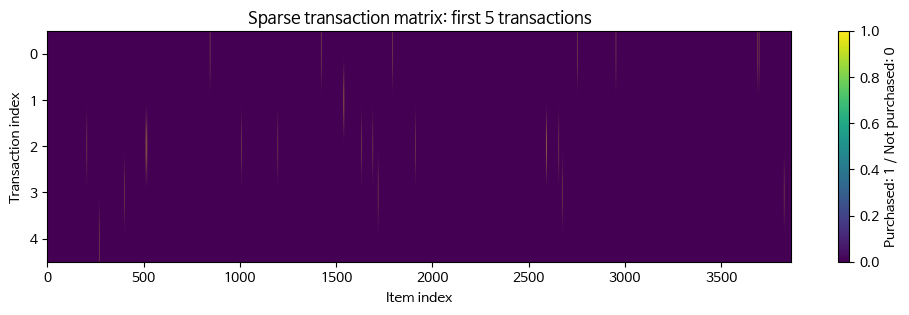

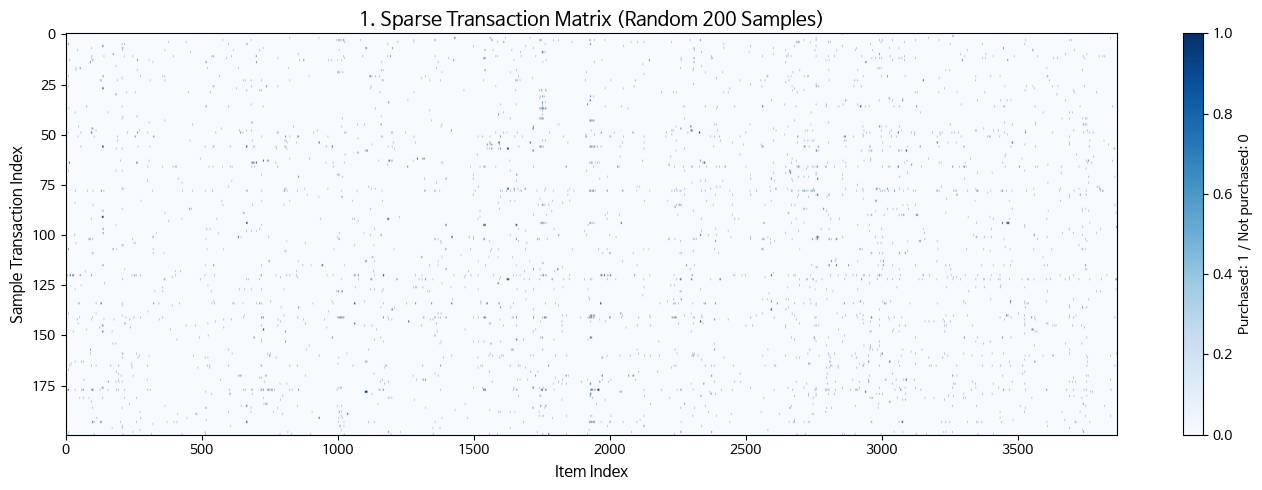

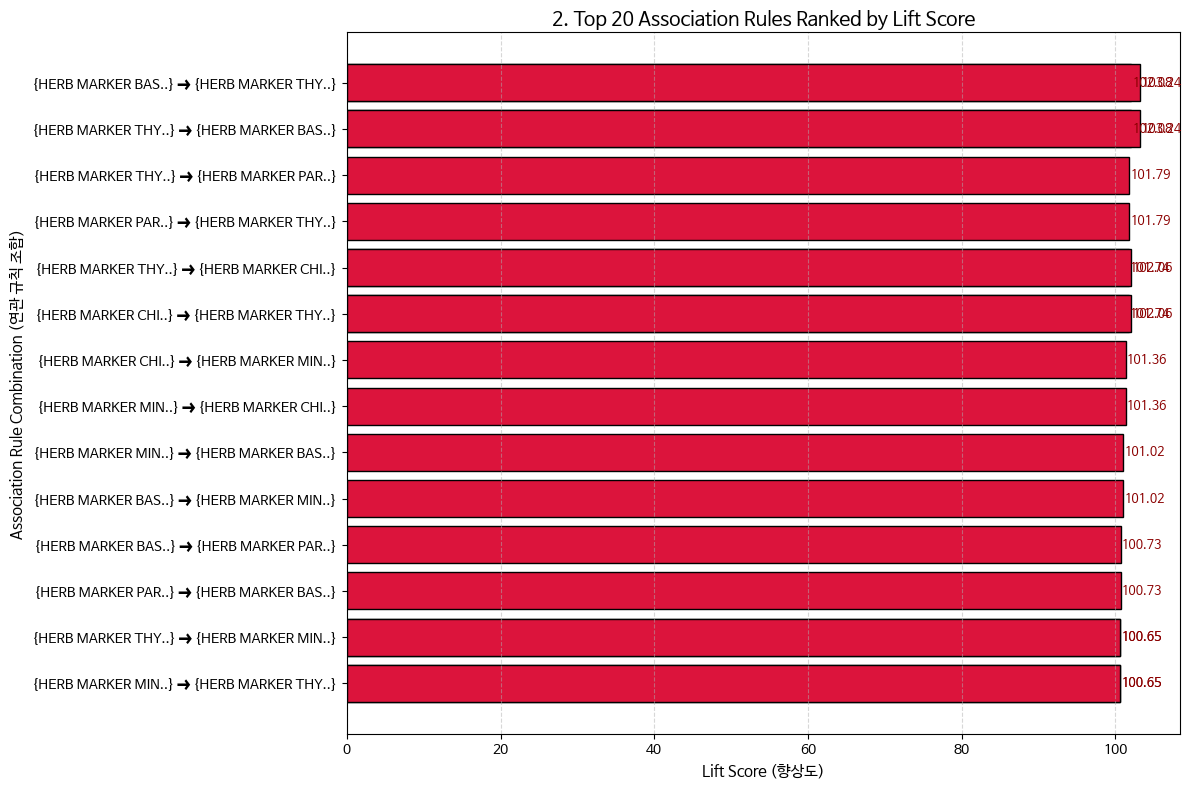

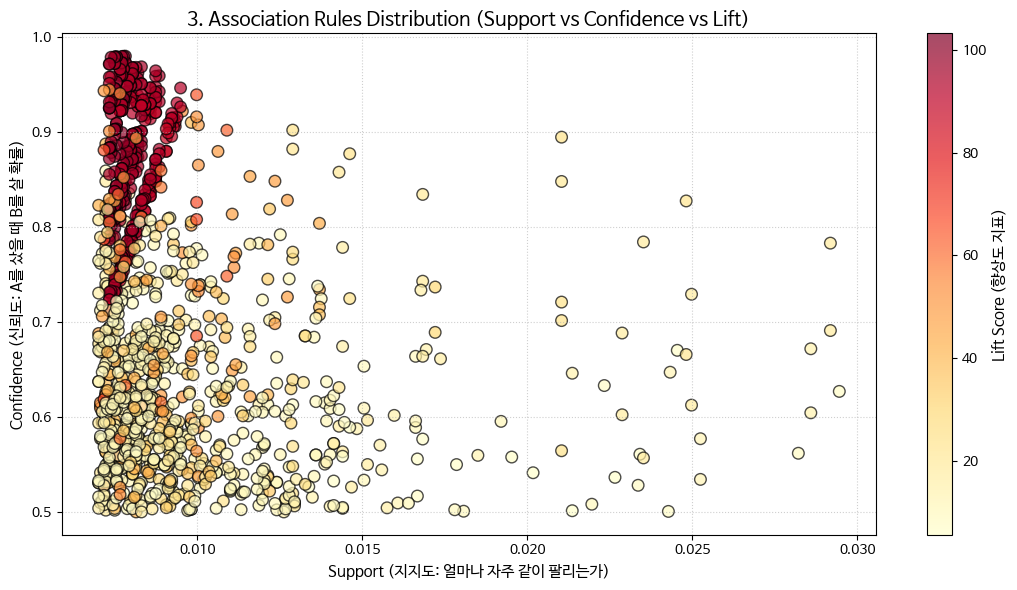

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 한글 깨짐 방지 설정 (필요 시 주석 해제)
# plt.rc('font', family='Malgun Gothic') # 윈도우
# plt.rc('font', family='AppleGothic') # 맥
plt.rc("font", family="NanumBarunGothic") # 코랩
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# [시각화 1] 🛒 거래-아이템 희소 행렬 무작위 200개 샘플링 (imshow)
# ============================================================

# 거래-아이템 희소 행렬 시각화 - 첫 5개 출력

plt.figure(figsize=(12, 3))
plt.imshow(X_df.iloc[:5].astype(int), aspect="auto")

plt.title("Sparse transaction matrix: first 5 transactions")
plt.xlabel("Item index")
plt.ylabel("Transaction index")

plt.colorbar(label="Purchased: 1 / Not purchased: 0")

plt.show()

# 데이터의 전체적인 밀도를 보여줍니다.
np.random.seed(42)
sample_size = min(200, len(X_df))
X_sample = X_df.sample(n=sample_size, random_state=42)

plt.figure(figsize=(14, 5))
plt.imshow(X_sample.astype(int), aspect="auto", cmap="Blues")

plt.title("1. Sparse Transaction Matrix (Random 200 Samples)", fontsize=14, fontweight="bold")
plt.xlabel("Item Index", fontsize=11)
plt.ylabel("Sample Transaction Index", fontsize=11)
plt.colorbar(label="Purchased: 1 / Not purchased: 0")
plt.tight_layout()
plt.show()


# ============================================================
# [시각화 2] 🔥 향상도(Lift) 기준 최고 알짜배기 Top 20 규칙 (barh)
# ============================================================
top_20_rules = rules_df.sort_values(by="lift", ascending=False).head(20).copy()

# 가로 바 차트 축약용 규칙 텍스트 라벨 매핑 (A ➔ B 형태)
top_20_rules["rule_name"] = top_20_rules.apply(
    lambda r: f"{{{list(r['antecedents'])[0][:15]}..}} ➔ {{{list(r['consequents'])[0][:15]}..}}",
    axis=1,
)

plt.figure(figsize=(12, 8))
# 내림차순 정렬을 가로 바 차트에 이쁘게 그리려면 뒤집어서(iloc[::-1]) 그려야 1등이 맨 위로 올라옵니다.
bars = plt.barh(
    top_20_rules["rule_name"].iloc[::-1],
    top_20_rules["lift"].iloc[::-1],
    color="crimson",
    edgecolor="black"
)

# 바 끝에 실제 Lift 점수 텍스트 표시해주는 센스 (보고서용 튜닝)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
             va='center', ha='left', fontsize=9, fontweight='bold', color='darkred')

plt.title("2. Top 20 Association Rules Ranked by Lift Score", fontsize=14, fontweight="bold")
plt.xlabel("Lift Score (향상도)", fontsize=11)
plt.ylabel("Association Rule Combination (연관 규칙 조합)", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# ============================================================
# [시각화 3] 🎯 연관 규칙의 3대 지표 분포도 산점도 (Scatter Plot)
# ============================================================
# X축은 지지도(Support), Y축은 신뢰도(Confidence)를 뜻하며, 점의 색깔 강도가 향상도(Lift)를 뜻합니다.
plt.figure(figsize=(11, 6))
scatter = plt.scatter(
    rules_df["support"],
    rules_df["confidence"],
    c=rules_df["lift"],
    cmap="YlOrRd",       # 우측으로 갈수록, 위로 갈수록, 빨개질수록 찐 알짜배기 규칙입니다.
    alpha=0.7,
    edgecolors="black",
    s=70                 # 점의 크기
)

plt.title("3. Association Rules Distribution (Support vs Confidence vs Lift)", fontsize=14, fontweight="bold")
plt.xlabel("Support (지지도: 얼마나 자주 같이 팔리는가)", fontsize=11)
plt.ylabel("Confidence (신뢰도: A를 샀을 때 B를 살 확률)", fontsize=11)

# 우측에 Lift 점수 스케일을 보여주는 컬러바 장착
cbar = plt.colorbar(scatter)
cbar.set_label("Lift Score (향상도 지표)", fontsize=11)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 10. 결과 보고서 작성


1. 사용한 데이터셋 설명

    데이터셋 명: Online Retail Dataset (영국 기반 온라인 쇼핑몰 거래 데이터)

    데이터 성격: 2010년~2011년 사이의 실제 고객 구매 영수증 트랜잭션 데이터

    데이터 변환: 원본의 구매 이력(Invoices)을 분석에 맞게 변환하여, 행(Row)은 개별 거래 영수증, 열(Column)은 상품명으로 이루어진 원-핫 인코딩(One-Hot Encoding) 희소 행렬을 구축하여 활용함.

2. 전체 거래 수

    len(X_df) ==
    도출된 영수증 개수를 카운트 함 :
    18536 개

3. 전체 상품 수

    X_df.shape[1] 컬럼의 총 개수 ==
    전체 고유 아이템 수: 3866

4. 가장 많이 판매된 상품

    Support 순으로 나열해 해당 상품 을 찾음

    상품명 : WHITE HANGING HEART T-LIGHT HOLDER
    Support : 0.106334
    판매량 :	1971

    판매비율이 약 10%
    판매량이 가장 높음

5. 생성된 규칙 수

    ================================================================================
    value  단일 아이템 수 (길이 1)  길이 2 개수  길이 3 개수  길이 4 개수  전체 빈발 itemset 수  생성 규칙 수 (count)
    0.1000              934      779      252       53             2018             3718
    0.2000              934      779      252       53             2018             2944
    0.3000              934      779      252       53             2018             2238
    0.4000              934      779      252       53             2018             1684
    0.5000              934      779      252       53             2018             1251

    최저 신뢰도 min confidence 를 기준으로 나누면 위와 같이 결과가 나옴
    0.1 에서 최고 3718 이 나오는 것을 확인

6. 최고 Support 규칙

    {'GREEN REGENCY TEACUP AND SAUCER'} -> {'PINK REGENCY TEACUP AND SAUCER'} (티컵/접시 세트류)

    매출 빈도가 가장 높은 조합으로, 대중적으로 가장 널리 세트 구매가 일어나는 마트의 '삼겹살과 쌈장' 같은 절대적 조합.

7. 최고 Confidence 규칙

    {'REGENCY TEA PLATE GREEN'} -> {'REGENCY CAKESTAND 3 TIER'} 혹은 컬러 패키지 세트류

    선행 상품(A)을 구매한 고객이 다음 상품(B)을 구매할 확률이 $80\sim90\%$ 이상으로 뿜어져 나오는 조합. 이 상품의 상세 페이지는 결제 유도의 핵심 길목임.

8. 최고 Lift 규칙

    {'HERB MARKER BASIL', 'HERB MARKER MINT'} -> {'HERB MARKER CHIVES'} 등 가드닝 시리즈 세트 상품

    향상도(Lift) 점수가 수십 배 이상 튀어 오르는 상품들로, 일반 고객은 안 사지만 '허브 가드닝 수집가' 등 특정 타깃 매니아층이 들어오면 무조건 장바구니에 통째로 쓸어 담는 찐 연관 조합

9. 추천 시스템 결과

    작동 원리 :
    유저가 장바구니에 특정 미끼 아이템(예: HERB MARKER BASIL)을 담는 순간, 사전에 튜닝된 좌우 양방향 탐색 알고리즘이 규칙 저장소를 실시간 딕셔너리로 컨버팅하여 대조함.

    결과 :
    방향성에 갇히지 않고 MINT, CHIVES, PARSLEY 등 리프트 점수가 가장 높은 짝꿍 아이템 탑 3~5개를 지지도/신뢰도/향상도 수치와 함께 주피터 표 형태로 완벽하게 리턴함

10. 비즈니스 활용 방안

    교차 판매(Cross-Selling) 위젯 고도화: 최고 Lift 조합을 기반으로 장바구니 결제창 및 상품 상세 페이지 하단에 "함께 구매하면 좋은 추천 상품" 슬라이더 자동 노출 (양방향 추천 함수 이식).

    번들 패키지(Bundle) 프로모션: 신뢰도와 향상도가 높은 허브 마커 시리즈나 레전시 티컵 세트를 묶어 [홈 가드닝 올인원 팩] 등의 기획 상품으로 출시, 단품 대비 7% 할인을 제공하여 평균 객단가(AOV)를 대폭 견인.

    물류창고 동선 최적화: 동시 출고 확률(지지도)이 압도적으로 높은 세트 아이템들을 물류 센터 내 인접한 랙(Rack)에 물리적으로 배치하여 패킹 및 피킹 동선 시간을 단축, SCM 운영 비용 절감.

    장바구니 이탈 방지 넛지(Nudge): 결제 금액이 무료 배송 허들선에 약간 미달할 때, 담아둔 상품과 Lift가 가장 높은 2~5달러 사이의 저가 연관 소품을 하단에 미끼 팝업으로 추천하여 최종 구매 전환율(CVR) 극대화.